In [65]:
from __future__ import print_function
import argparse
import sys
import os
import random
import torch
import torch.nn as nn
import torch.nn.parallel
import torch.backends.cudnn as cudnn
import torch.optim as optim
import torch.utils.data
import torchvision
import torchvision.datasets as dset
import torchvision.transforms as transforms
import torchvision.utils as vutils
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import math
from IPython.display import HTML
import time
import pandas as pd
import pickle

# Get the current working directory (the folder where the .ipynb is)
current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, ".."))

if parent_dir not in sys.path:
    sys.path.append(parent_dir)

from lib.utils.SaveAnimation import Video
from lib.models import Generator, Discriminator

In [66]:
# Get GPU Information
print("CUDA is available: {}".format(torch.cuda.is_available()))
print("CUDA Device Count: {}".format(torch.cuda.device_count()))
print(
    "CUDA Device Name: {}".format(
        torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No CUDA device"
    )
)

CUDA is available: False
CUDA Device Count: 0
CUDA Device Name: No CUDA device


In [67]:
# Location of Training Data
spectra_path = f"{parent_dir}\\data\\absorptionData_HybridGAN.csv"

# Root directory for dataset (images must be in a subdirectory within this folder)
img_data_path = f"{parent_dir}\\data"

In [68]:
def Excel_Tensor(spectra_path):
    # Location of excel data
    excelData = pd.read_csv(spectra_path, header=0, index_col=0)
    excelDataSpectra = excelData.iloc[
        :, :800
    ]  # index until the last point of the spectra in the Excel file
    excelDataTensor = torch.tensor(excelDataSpectra.values).type(torch.FloatTensor)
    return excelData, excelDataSpectra, excelDataTensor


excelData, excelDataSpectra, excelDataTensor = Excel_Tensor(spectra_path)


In [69]:
## -------- EXPERIMENT SETTINGS -------- ##

# set a trial name for saving results
trial_name = "trial_hopefully_good"

# set manual seeds
manualSeed = 12345

## ----- TRAINING HYPERPARAMETERS ----- ##

# Number of workers for dataloader (for Windows workers must = 0, for reference: https://github.com/pytorch/pytorch/issues/2341)
workers = 1

# Batch size during training
batch_size = 16

# Spatial size of training images. All images will be resized to this size using a transformer.
image_size = 64

# Number of channels in the training images. For color images this is 3
nc = 3

# Size of z latent vector (i.e. size of generator input)
latent = 400
gan_input = excelDataTensor.size()[1] + latent

# Size of feature maps in generator
ngf = 128

# Size of feature maps in discriminator
ndf = 64

# Number of training epochs
num_epochs = 25  # TODO: change back to 500

# Learning rate for optimizers
lr = 0.0001

# Beta1 hyperparam for Adam optimizers
beta1 = 0.5

# Number of GPUs available. Use 0 for CPU mode.
ngpu = 1

# Initialize BCELoss function
criterion = nn.BCELoss()


# ------------ DEVELOPER SETUP ------------- #

verbose_every_n_batches = 25  # TODO: change it to 50
break_after_n_batches = 250  # TODO: change to None for full training
save_model_every_n_epochs = 25  # TODO: change it to 50
save_images_every_n_iters = 150  # TODO: change it to 500

In [70]:
settings_string = f"""Experiment Settings:
Trial Name: {trial_name}
Manual Seed: {manualSeed}
Batch Size: {batch_size}
Image Size: {image_size}
Latent Vector Size: {latent}
Generator Feature Map Size: {ngf}
Discriminator Feature Map Size: {ndf}
Number of Epochs: {num_epochs}
Learning Rate: {lr}
Beta1: {beta1}
Number of GPUs: {ngpu}
Verbose Every N Batches: {verbose_every_n_batches}
Break After N Batches: {break_after_n_batches}
Save Model Every N Epochs: {save_model_every_n_epochs}
Save Images Every N Iters: {save_images_every_n_iters}
"""
print(settings_string)

Experiment Settings:
Trial Name: trial_hopefully_good
Manual Seed: 12345
Batch Size: 16
Image Size: 64
Latent Vector Size: 400
Generator Feature Map Size: 128
Discriminator Feature Map Size: 64
Number of Epochs: 25
Learning Rate: 0.0001
Beta1: 0.5
Number of GPUs: 1
Verbose Every N Batches: 25
Break After N Batches: 250
Save Model Every N Epochs: 25
Save Images Every N Iters: 150



In [71]:
time_stamp = time.strftime("%Y%m%d-%H%M%S")
trial_name = f"{trial_name}_{time_stamp}"

# Location to Save Models and results (Generators and Discriminators)
results_dir = f"{parent_dir}\\results\\{trial_name}"
save_dir = f"{parent_dir}\\results\\{trial_name}\\models"

# create results directory if it doesn't exist
os.makedirs(results_dir, exist_ok=True)
os.makedirs(save_dir, exist_ok=True)

In [72]:
# set the training log
f = open(results_dir + "\\training_log.txt", "w")
f.write(f"Trial Name: {trial_name}\n")

print(f"Saving the logs to: {results_dir}\\training_log.txt")

print(settings_string, file=f)

start_time = time.time()
local_time = time.ctime(start_time)
print("Start Time = %s" % local_time)
print("Start Time = %s" % local_time, file=f)

Saving the logs to: d:\Adhil\Github\GenAI_project\results\trial_hopefully_good_20260430-195315\training_log.txt
Start Time = Thu Apr 30 19:53:15 2026


In [73]:
print("Random Seed: ", manualSeed)
random.seed(manualSeed)
torch.manual_seed(manualSeed)

Random Seed:  12345


In [74]:
dataset = dset.ImageFolder(
    root=img_data_path,
    transform=transforms.Compose(
        [
            transforms.Resize(image_size),
            transforms.CenterCrop(image_size),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5]),
        ]
    ),
)
# Create the dataloader
dataloader = torch.utils.data.DataLoader(
    dataset, batch_size=batch_size, shuffle=False, num_workers=workers
)

# Decide which device we want to run on
device = torch.device("cuda:0" if (torch.cuda.is_available() and ngpu > 0) else "cpu")

In [75]:
# Custom weights initialization called on netG and netD
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find("Conv") != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find("BatchNorm") != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

In [76]:
# create the generator and discriminator


netG = Generator(ngpu, gan_input=gan_input, ngf=ngf, nc=nc).to(device)

# Handle multi-gpu if desired
if (device.type == "cuda") and (ngpu > 1):
    netG = nn.DataParallel(netG, list(range(ngpu)))

# Apply the weights_init function to randomly initialize all weights to mean=0, stdev=0.2.
netG.apply(weights_init)

# Print the model
print(netG)


# Create the Discriminator
netD = Discriminator(ngpu, ndf=ndf, nc=nc, image_size=image_size).to(device)

# Handle multi-gpu if desired
if (device.type == "cuda") and (ngpu > 1):
    netD = nn.DataParallel(netD, list(range(ngpu)))

# Apply the weights_init function to randomly initialize all weights to mean=0, stdev=0.2.
netD.apply(weights_init)

# Print the model
print(netD)


Generator(
  (conv1): ConvTranspose2d(1200, 1024, kernel_size=(6, 6), stride=(1, 1), bias=False)
  (conv2): BatchNorm2d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): ReLU(inplace=True)
  (conv4): ConvTranspose2d(1024, 512, kernel_size=(6, 6), stride=(2, 2), padding=(2, 2), bias=False)
  (conv5): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv6): ReLU(inplace=True)
  (conv7): ConvTranspose2d(512, 256, kernel_size=(6, 6), stride=(2, 2), padding=(4, 4), bias=False)
  (conv8): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv9): ReLU(inplace=True)
  (conv10): ConvTranspose2d(256, 128, kernel_size=(6, 6), stride=(2, 2), padding=(5, 5), bias=False)
  (conv11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv12): ReLU(inplace=True)
  (conv13): ConvTranspose2d(128, 3, kernel_size=(6, 6), stride=(2, 2), padding=(4, 4), bias=False)
  (conv14):

In [77]:
# Create batch of latent vectors that we will use to visualize the progression of the generator
testTensor = torch.Tensor()
for i in range(100):
    fixed_noise1 = torch.cat(
        (
            excelDataTensor[i * int(np.floor(len(excelDataSpectra) / 100))],
            torch.rand(latent),
        )
    )
    fixed_noise2 = fixed_noise1.unsqueeze(1).unsqueeze(1).unsqueeze(1)
    fixed_noise = fixed_noise2.permute(1, 0, 2, 3)
    testTensor = torch.cat((testTensor, fixed_noise), 0)
testTensor = testTensor.to(device)

# Establish convention for real and fake labels during training
real_label = random.uniform(0.9, 1.0)
fake_label = 0

In [ ]:
# Setup Adam optimizers for both G and D
optimizerD = optim.Adam(netD.parameters(), lr=lr, betas=(beta1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=lr, betas=(beta1, 0.999))

##Training Loop
# Lists to keep track of progress
img_list = []
G_losses = []
D_losses = []
iters = 0
noise = torch.Tensor()
noise2 = torch.Tensor()
print("Starting Training Loop...")
# For each epoch
x = 0
for epoch in range(num_epochs):
    x = 0
    # For each batch in the dataloader
    for i, data in enumerate(dataloader, 0):
        ############################
        # (1) Update D network: maximize log(D(x)) + log(1 - D(G(z)))
        ###########################
        ## Train with all-real batch
        netD.zero_grad()
        # Format batch
        real_cpu = data[0].to(device)
        b_size = real_cpu.size(0)
        label = torch.full((b_size,), real_label, device=device)

        # Generate batch of Spectra,  latent vectors, and Properties
        for j in range(batch_size):
            excelIndex = x * batch_size + j
            try:
                gotdata = excelDataTensor[excelIndex]
            except IndexError:
                break
            tensorA = excelDataTensor[excelIndex].view(1, 800)
            noise2 = torch.cat((noise2, tensorA), 0)

            tensor1 = torch.cat((excelDataTensor[excelIndex], torch.rand(latent)))
            tensor2 = tensor1.unsqueeze(1).unsqueeze(1).unsqueeze(1)
            tensor3 = tensor2.permute(1, 0, 2, 3)
            noise = torch.cat((noise, tensor3), 0)

        noise = noise.to(device)
        noise2 = noise2.to(device)

        # Forward pass real batch through D
        output = netD.forward(real_cpu, noise2, batch_size=b_size).view(-1)
        # Calculate loss on all-real batch
        errD_real = criterion(output, label)
        # Calculate gradients for D in backward pass
        errD_real.backward()
        D_x = output.mean().item()

        ## Train with all-fake batch
        # Generate fake image batch with G
        fake = netG.forward(noise)
        label.fill_(fake_label)
        # Classify all fake batch with D
        output = netD.forward(fake.detach(), noise2, batch_size=b_size).view(-1)
        # Calculate D's loss on the all-fake batch
        errD_fake = criterion(output, label)
        # Calculate the gradients for this batch
        errD_fake.backward()
        D_G_z1 = output.mean().item()
        # Add the gradients from the all-real and all-fake batches
        errD = errD_real + errD_fake
        # Update D
        optimizerD.step()

        ############################
        # (2) Update G network: maximize log(D(G(z)))
        ###########################
        netG.zero_grad()
        label.fill_(real_label)  # fake labels are real for generator cost
        # Since we just updated D, perform another forward pass of all-fake batch through D
        output = netD.forward(fake, noise2, batch_size=b_size).view(-1)
        # Calculate G's loss based on this output
        errG = criterion(output, label)
        # Calculate gradients for G
        errG.backward()
        D_G_z2 = output.mean().item()
        # Update G
        optimizerG.step()

        # Output training stats
        if i==0 or ((i+1) % verbose_every_n_batches == 0):
            print(
                "e[%d/%d]b[%d/%d]\tLoss_D: %.4f\tLoss_G: %.4f\tD(x): %.4f\tD(G(z)): %.4f / %.4f"
                % (
                    epoch + 1,
                    num_epochs,
                    i + 1,
                    len(dataloader)
                    if break_after_n_batches is None
                    else break_after_n_batches,
                    errD.item(),
                    errG.item(),
                    D_x,
                    D_G_z1,
                    D_G_z2,
                )
            )
            print(
                "e[%d/%d]b[%d/%d]\tLoss_D: %.4f\tLoss_G: %.4f\tD(x): %.4f\tD(G(z)): %.4f / %.4f"
                % (
                    epoch + 1,
                    num_epochs,
                    i + 1,
                    len(dataloader)
                    if break_after_n_batches is None
                    else break_after_n_batches,
                    errD.item(),
                    errG.item(),
                    D_x,
                    D_G_z1,
                    D_G_z2,
                ),
                file=f,
            )

        # Save Losses for plotting later
        G_losses.append(errG.item())
        D_losses.append(errD.item())

        #  Check how the generator is doing by saving G's output on fixed_noise
        if (
            (iters % save_images_every_n_iters == 0)
            or ((epoch == num_epochs - 1) and (i == len(dataloader) - 1))
            or ((i == break_after_n_batches - 1) and (epoch == num_epochs - 1))
        ):
            with torch.no_grad():
                fake = netG(testTensor).detach().cpu()
            img_list.append(vutils.make_grid(fake, nrow=10, padding=2, normalize=True))

        iters += 1
        noise = torch.Tensor()
        noise2 = torch.Tensor()
        x += 1

        if break_after_n_batches is not None and i == (break_after_n_batches - 1):
            print(
                f"Breaking after {break_after_n_batches} batches for developer testing."
            )
            break

    if epoch % (save_model_every_n_epochs - 1) == 0:
        ##Update folder location
        torch.save(netG, save_dir + "\\netG" + str(epoch) + ".pt")
        torch.save(netD, save_dir + "\\netD" + str(epoch) + ".pt")


local_time = time.ctime(time.time())
print("End Time = %s" % local_time)
print("End Time = %s" % local_time, file=f)
run_time = (time.time() - start_time) / 3600
print("Total Time Lapsed = %s Hours" % run_time)
print("Total Time Lapsed = %s Hours" % run_time, file=f)
f.close()

Starting Training Loop...
e[1/25]b[1/250]	Loss_D: 1.7394	Loss_G: 22.0647	D(x): 0.8295	D(G(z)): 0.7224 / 0.0000
e[1/25]b[26/250]	Loss_D: 3.9658	Loss_G: 0.2839	D(x): 0.1032	D(G(z)): 0.1395 / 0.9425
e[1/25]b[51/250]	Loss_D: 3.1308	Loss_G: 2.8452	D(x): 0.2039	D(G(z)): 0.6064 / 0.1222
e[1/25]b[76/250]	Loss_D: 3.8827	Loss_G: 4.4453	D(x): 0.8092	D(G(z)): 0.9668 / 0.0095
e[1/25]b[101/250]	Loss_D: 4.0649	Loss_G: 8.4040	D(x): 0.9107	D(G(z)): 0.9656 / 0.0003
e[1/25]b[126/250]	Loss_D: 2.0070	Loss_G: 4.4964	D(x): 0.2302	D(G(z)): 0.0149 / 0.0118
e[1/25]b[151/250]	Loss_D: 2.4418	Loss_G: 7.0857	D(x): 0.8676	D(G(z)): 0.8510 / 0.0009
e[1/25]b[176/250]	Loss_D: 1.4347	Loss_G: 2.5307	D(x): 0.5913	D(G(z)): 0.4823 / 0.0919
e[1/25]b[201/250]	Loss_D: 3.5206	Loss_G: 0.2829	D(x): 0.0382	D(G(z)): 0.1641 / 0.8340
e[1/25]b[226/250]	Loss_D: 0.7765	Loss_G: 2.4957	D(x): 0.7894	D(G(z)): 0.3378 / 0.0883
Breaking after 250 batches for developer testing.
e[2/25]b[1/250]	Loss_D: 5.8564	Loss_G: 0.3130	D(x): 0.0046	D(G(z)): 

Animation size has reached 21071391 bytes, exceeding the limit of 20971520.0. If you're sure you want a larger animation embedded, set the animation.embed_limit rc parameter to a larger value (in MB). This and further frames will be dropped.
MovieWriter ffmpeg unavailable; using Pillow instead.


Saved training progress video to: d:\Adhil\Github\GenAI_project\results\trial_1_20260430-194154/animation.gif


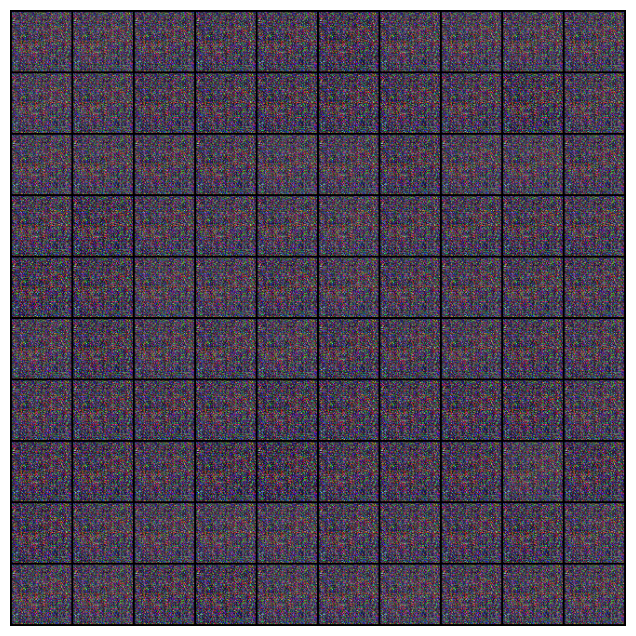

In [ ]:
# Save training progress video
format_type = "gif"
frames_per_second = 5
ims, ani = Video.save_video(results_dir, img_list, G_losses, D_losses, format=format_type, fps=frames_per_second)
print(f"Saved training progress video to: {results_dir}/animation.{format_type}")

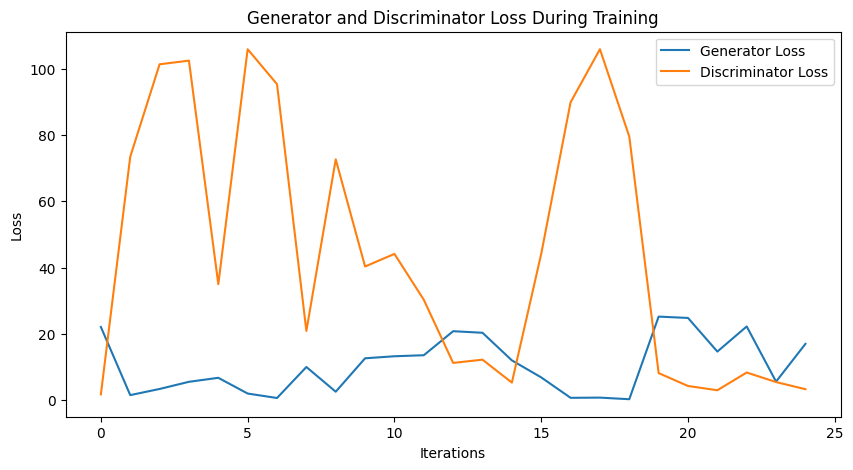

Saved training losses plot to: d:\Adhil\Github\GenAI_project\results\trial_1_20260430-194154\losses.png


In [ ]:
# Plot and save G and D Training Losses
plt.figure(figsize=(10, 5))
plt.title("Generator and Discriminator Loss During Training")
plt.plot(G_losses, label="Generator Loss")
plt.plot(D_losses, label="Discriminator Loss")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.savefig(os.path.join(results_dir, "losses.png"))
plt.show()
print(f"Saved training losses plot to: {results_dir}\\losses.png")